In [43]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import numpy as np

In [44]:
# Load the merged data from Excel
df = pd.read_excel("merged_data.xlsx", sheet_name = "Sheet1")
print(df.head())

  Year_Month  Year  Month  Spot_Price        CPI  YoY_Inflation
0 2002-01-01  2002      1       19.42  57.541961       4.943862
1 2002-02-01  2002      2       20.28  57.418721       5.191865
2 2002-03-01  2002      3       23.70  57.665144       5.168521
3 2002-04-01  2002      4       25.73  57.788385       4.687518
4 2002-05-01  2002      5       25.35  58.158048       4.656368


In [45]:
# Basic descriptive statistics
stats = df[["Spot_Price", "CPI", "YoY_Inflation"]].describe().T
stats["skew"] = df[["Spot_Price", "CPI", "YoY_Inflation"]].skew().round(2)
stats["kurtosis"] = df[["Spot_Price", "CPI", "YoY_Inflation"]].kurtosis().round(2)
print(stats.round(2).T)

          Spot_Price     CPI  YoY_Inflation
count         285.00  285.00         285.00
mean           70.21  132.99           6.18
std            26.88   55.41           2.75
min            18.38   57.42           1.54
25%            49.99   76.17           4.18
50%            68.61  135.57           5.51
75%            86.51  175.52           7.79
max           132.72  235.14          16.22
skew            0.19    0.21           0.96
kurtosis       -0.75   -1.22           0.78


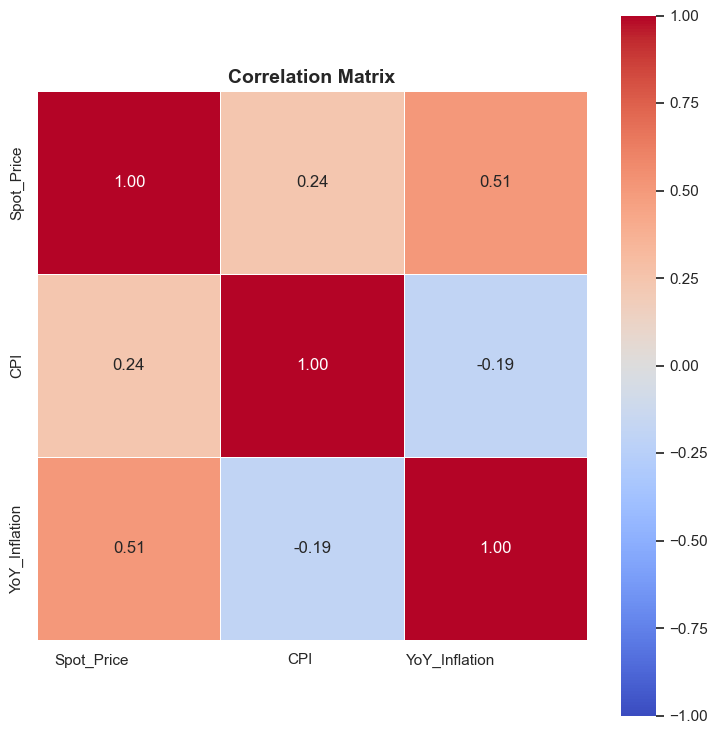

In [46]:
# Correlation matrix and heatmap
corrl = df[["Spot_Price", "CPI", "YoY_Inflation"]].corr()
plt.figure(figsize = (7.5, 7.5))
sns.heatmap(corrl, annot=True, cmap='coolwarm', vmin=-1, vmax=1, 
            linewidths=0.5, linecolor='white', square=True, fmt=".2f",
            annot_kws={"size": 12})
plt.title("Correlation Matrix", fontsize=14, weight = "bold")
plt.xticks(rotation=0, ha='right')
plt.yticks(rotation=90)
plt.tight_layout()
plt.show()

In [47]:
corr_coef, p_value = pearsonr(df["CPI"], df["Spot_Price"])
print(f"Pearson correlation = {corr_coef:.6f}, \np-value = {p_value:.6f}")

Pearson correlation = 0.241664, 
p-value = 0.000037


In [48]:
corr_coef, p_value = pearsonr(df["YoY_Inflation"], df["Spot_Price"])
print(f"Pearson correlation: {corr_coef:.6f}, \np-value: {p_value:.6f}")

Pearson correlation: 0.507016, 
p-value: 0.000000


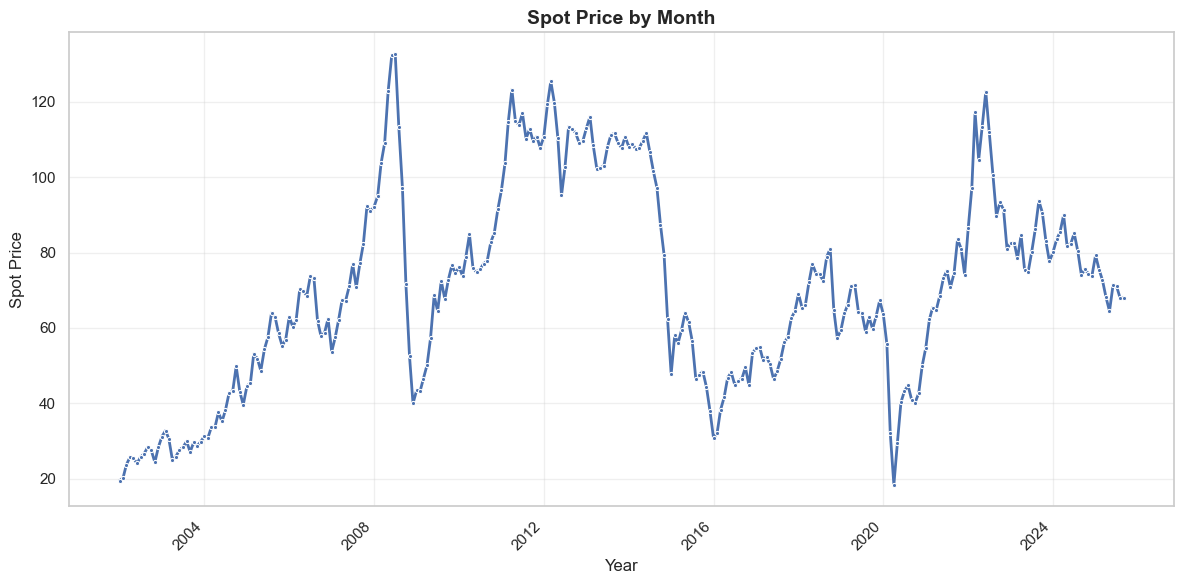

In [49]:
# Line plot of Spot Price by Month
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x="Year_Month", y="Spot_Price", marker=".", linewidth=2)
plt.title("Spot Price by Month", fontsize=14, weight="bold")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Spot Price", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

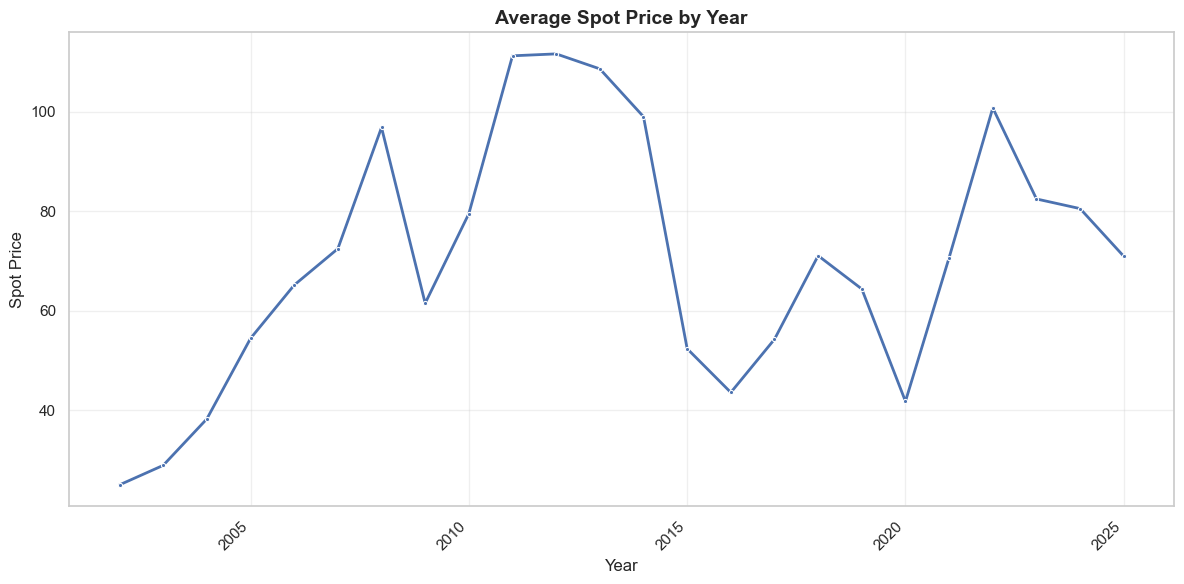

In [50]:
# Line plot of Average Spot Price by Year
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x="Year", y="Spot_Price", marker=".", linewidth=2, errorbar=None)
plt.title("Average Spot Price by Year", fontsize=14, weight="bold")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Spot Price", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [51]:
# Basic outlier event check using Inter-Quartile Range
Q1 = df["Spot_Price"].quantile([0.25, 0.5, 0.75])[0.25]
Q3 = df["Spot_Price"].quantile([0.25, 0.5, 0.75])[0.75]
IQR = Q3 - Q1
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR
print(lower_bound)
print(upper_bound)
outliers = df[(df["Spot_Price"] <= lower_bound) | (df["Spot_Price"] >= upper_bound)]
print("Outliers in Spot Price = \n", outliers)

-4.789999999999999
141.29000000000002
Outliers in Spot Price = 
 Empty DataFrame
Columns: [Year_Month, Year, Month, Spot_Price, CPI, YoY_Inflation]
Index: []


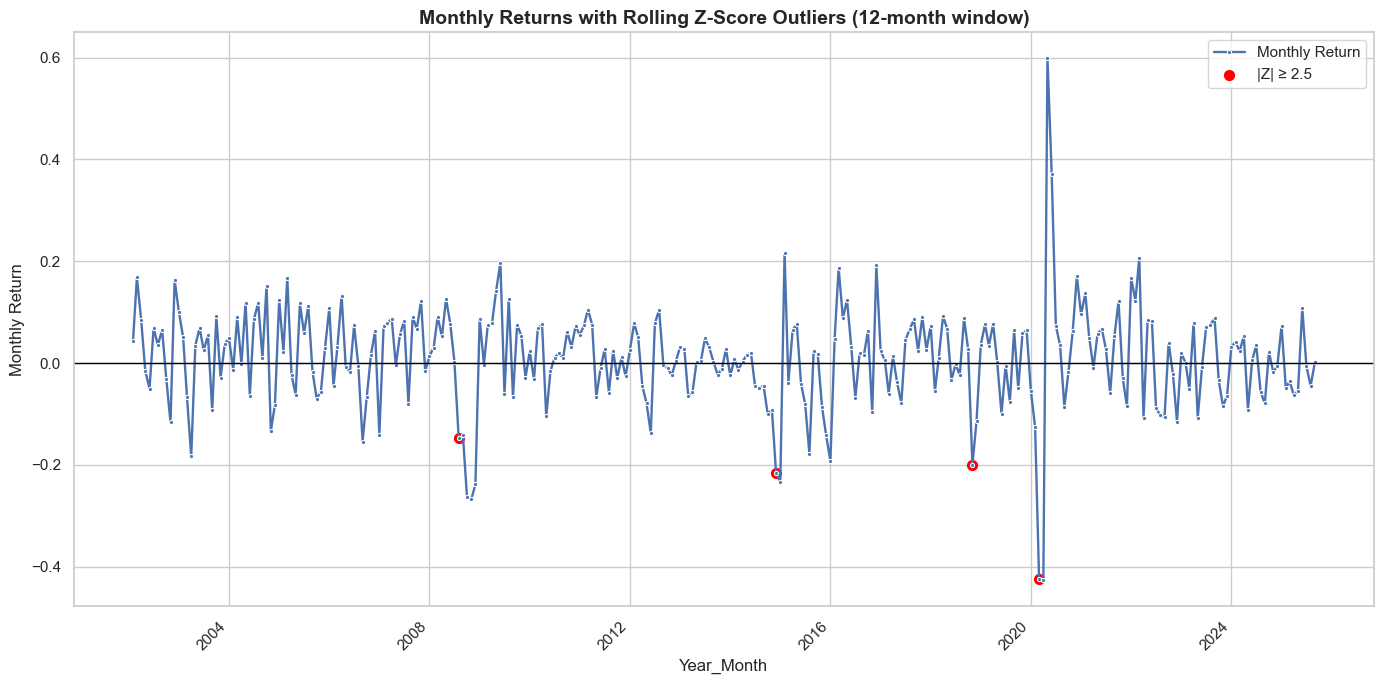


Largest Down Moves (monthly):
Year_Month
2020-04-01   -0.4258
2020-03-01   -0.4249
2008-11-01   -0.2673
2008-10-01   -0.2638
2008-12-01   -0.2383
Name: Spot_Price, dtype: float64

Largest Up Moves (monthly):
Year_Month
2020-05-01    0.5985
2020-06-01    0.3707
2015-02-01    0.2165
2022-03-01    0.2071
2009-06-01    0.1974
Name: Spot_Price, dtype: float64


In [52]:
# More robust outlier event check using monthly returns and rolling z score method
s = df.set_index("Year_Month")["Spot_Price"]

# Monthly returns
r = s.pct_change()
# 12-month rolling z-score
r_mean = r.rolling(12, min_periods=6).mean()
r_std  = r.rolling(12, min_periods=6).std()
r_z = (r - r_mean) / r_std
# Mask for outliers
outliers = r_z.abs() >= 2.5

plt.figure(figsize=(14, 7))
# Main line
sns.lineplot(x=r.index, y=r, marker=".", linewidth=1.7, label="Monthly Return")
# Baseline
plt.axhline(0, color="black", linewidth=1)
# Flagged outliers
plt.scatter(r.index[outliers], r[outliers], color="red", s=50, label="|Z| ≥ 2.5")
plt.title("Monthly Returns with Rolling Z-Score Outliers (12-month window)", fontsize=14, weight = "bold")
plt.ylabel("Monthly Return")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

# Outlier stats
print("\nLargest Down Moves (monthly):")
print(r.sort_values().head(5).round(4))

print("\nLargest Up Moves (monthly):")
print(r.sort_values(ascending=False).head(5).round(4))

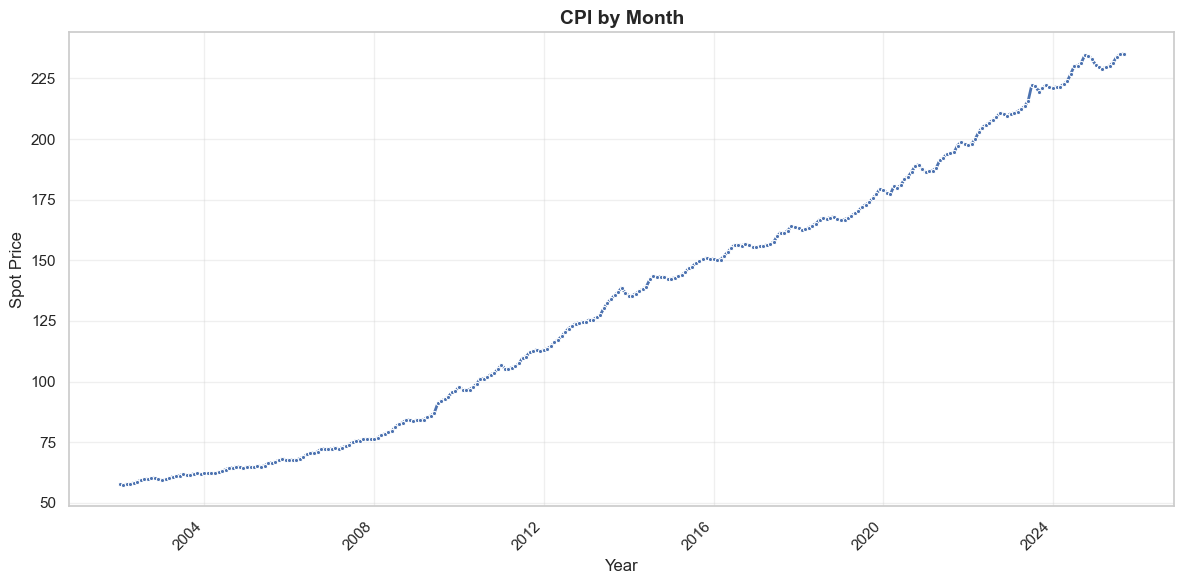

In [53]:
# Lineplot of India CPI by Month
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x="Year_Month", y="CPI", marker=".", linewidth=2)
plt.title("CPI by Month", fontsize=14, weight="bold")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Spot Price", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

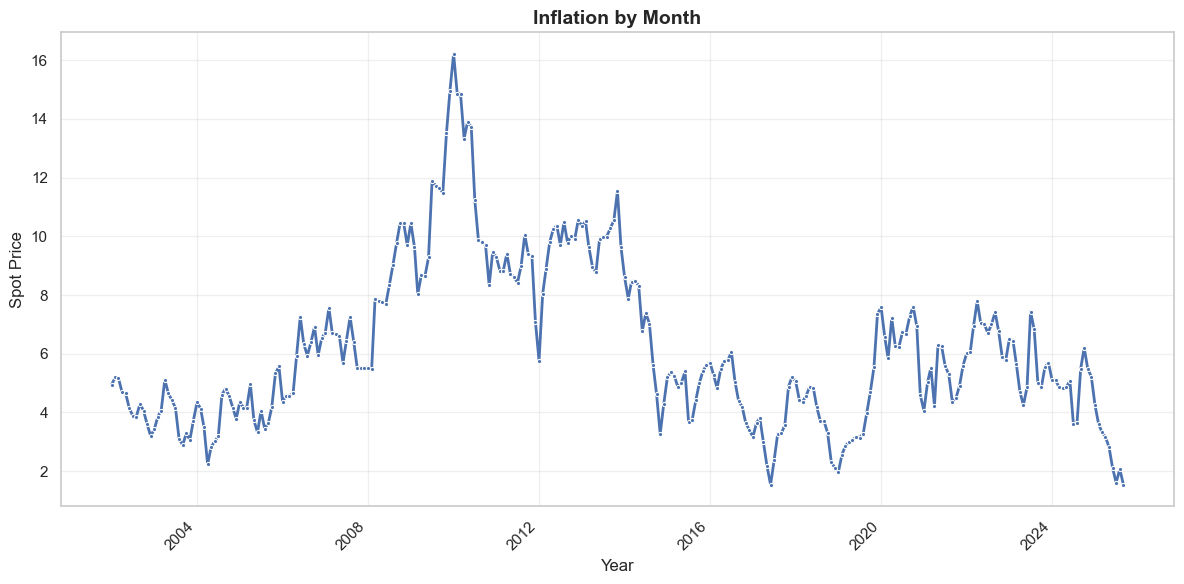

In [54]:
# Lineplot of India Inflation by Month
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x="Year_Month", y="YoY_Inflation", marker=".", linewidth=2)
plt.title("Inflation by Month", fontsize=14, weight="bold")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Spot Price", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

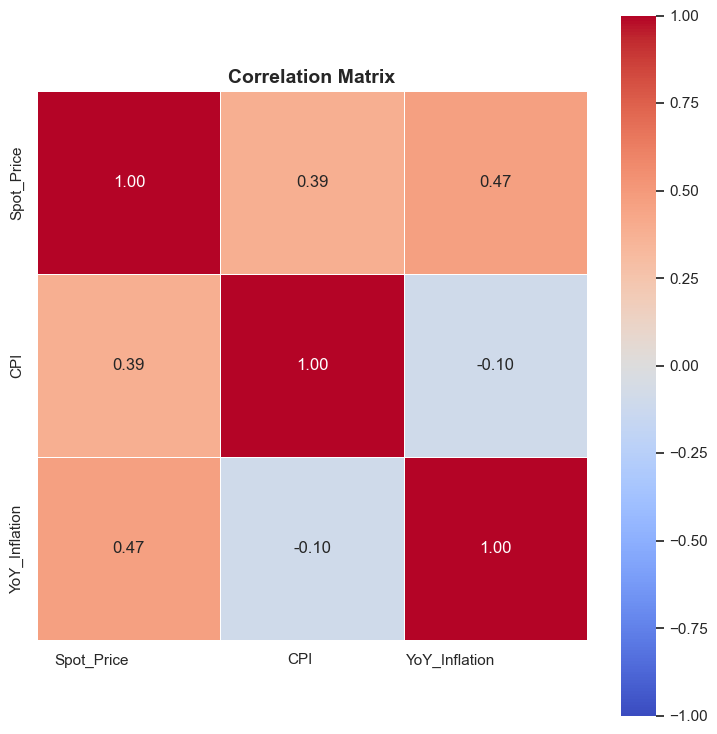

In [55]:
# Using log of varaibles for easier computation, interpretation, comparisions and visualisations
# Correlation matrix and heatmap in log scale
df_log = df[["Spot_Price", "CPI", "YoY_Inflation"]].apply(np.log)
corrl = df_log.corr()
plt.figure(figsize = (7.5, 7.5))
sns.heatmap(corrl, annot=True, cmap='coolwarm', vmin=-1, vmax=1, 
            linewidths=0.5, linecolor='white', square=True, fmt=".2f",
            annot_kws={"size": 12})
plt.title("Correlation Matrix", fontsize=14, weight = "bold")
plt.xticks(rotation=0, ha='right')
plt.yticks(rotation=90)
plt.tight_layout()
plt.show()

In [56]:
corr_coef, p_value = pearsonr(df_log["CPI"], df_log["Spot_Price"])
print(f"Pearson correlation = {corr_coef:.6f}, \np-value = {p_value:.6f}")

Pearson correlation = 0.385017, 
p-value = 0.000000


In [57]:
corr_coef, p_value = pearsonr(df_log["YoY_Inflation"], df_log["Spot_Price"])
print(f"Pearson correlation = {corr_coef:.6f}, \np-value = {p_value:.6f}")

Pearson correlation = 0.467173, 
p-value = 0.000000


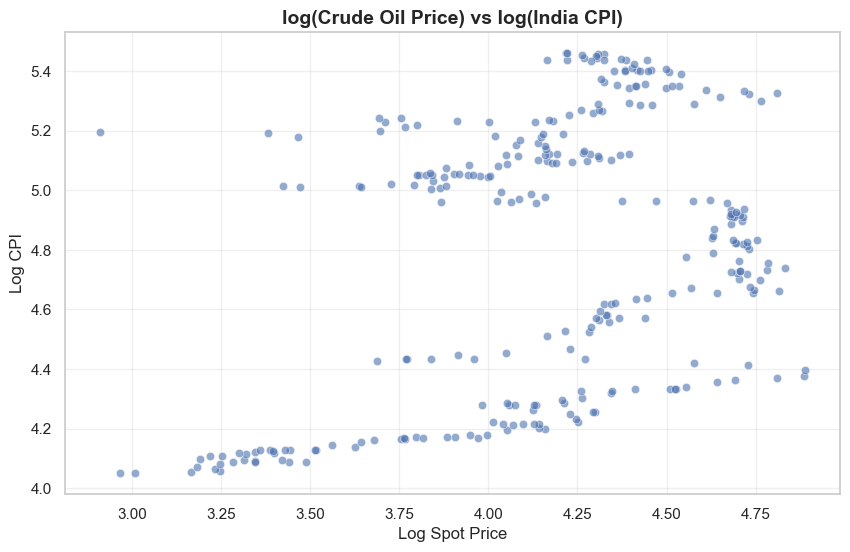

In [58]:
# Scatterplot of log(Crude Oil Price) vs log(CPI)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_log, x="Spot_Price", y="CPI", alpha=0.6)
plt.grid(alpha=0.3)
plt.title("log(Crude Oil Price) vs log(India CPI)", fontsize=14, weight = "bold")
plt.xlabel("Log Spot Price")
plt.ylabel("Log CPI")
plt.show()

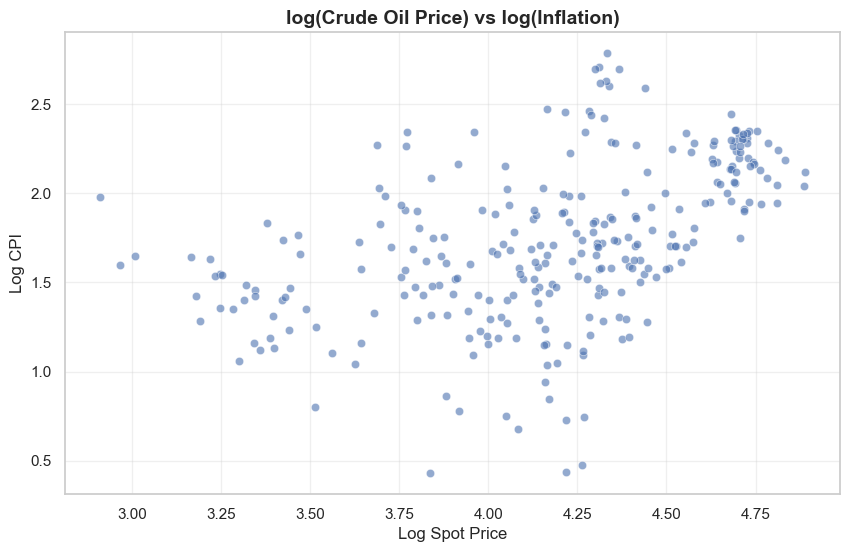

In [59]:
# Scatterplot of log(Crude Oil Price) vs log(Inflation)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_log, x="Spot_Price", y="YoY_Inflation", alpha=0.6)
plt.grid(alpha=0.3)
plt.title("log(Crude Oil Price) vs log(Inflation)", fontsize=14, weight = "bold")
plt.xlabel("Log Spot Price")
plt.ylabel("Log CPI")
plt.show()